In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import pandas
import functools 
import datetime
import scipy

import pmana.utils
import pmana.purity

#### Look at the purity of one measurement

There were 4 used channels in this measurement.


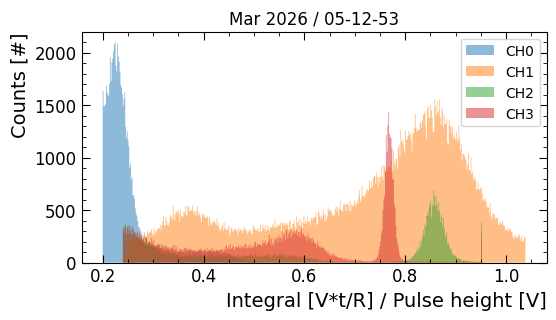

In [2]:
fig, ax = plt.subplots(figsize=(6,3))

YEAR = '2026'
MONTH = 'Mar'
MEASUREMENT = f'05_12_53'
FILE_PATH = f"../../data/cern_csv/{YEAR}_{MONTH}/Record_{YEAR}_{MONTH}_{MEASUREMENT}.csv"
# extract a measurement 
Data = pmana.utils.io.ExtractSingleMeasurement(
    FILE_PATH,
    IS_CSV = True,
    COL_NAMES = ['binCenter', 'F1', 'F2', 'F3', 'F4'],
    DELIMITER = ","
)
print(f"There were {len(Data)} used channels in this measurement.")

CHs = [1, 2, 3, 4]
for ch in CHs:
    # plot channel data
    pmana.utils.plotting.PlotSingleChannel(
        Data[ch-1],
        ax,
        channel = ch-1,
        rebin = False,
        debug = False,
        DISPLAY_FIT = False
    )

ax = pmana.utils.plotting.UpdateMatplotlibStyle(
    ax,
    "Integral [V*t/R] / Pulse height [V]",
    "Counts [#]"
)

ax.legend()
ax.set_title(f"{MONTH} {YEAR} / {MEASUREMENT.replace('_','-')}")
plt.show()
fig.savefig(f"../../plots/cern/RawData_{YEAR}_{MONTH}.png", dpi=300, bbox_inches='tight')

In [3]:
CalibrationFactors = {
  0: 1.1,
  1: 1,
  2: 1,
  3: 1
}

# ANALYSIS_CONFIGURATION = {
#     'InnerLongChannel'          : 0,
#     'OuterLongChannel'          : 1,
#     'InnerShortChannel'         : 3,
#     'OuterShortChannel'         : 2,  
#     'ShortGausFitLimits'        : (0.15, 0.15),
#     'LongGausFitLimits'         : (0.1, 0.15),
#     'ComptonSearchLimits'       : (0.5, 1),
#     'MinComptonSearchLowLimit'  : 0.25,
#     'ComptonMode'               : 'rising'
# }

pmana.purity.ana.ExtractICPeak(
  FILE_PATH,
  PM_TAG = 'Long',
  CALIBRATION_FACTORS = CalibrationFactors,
  # ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_05_12_53.csv...


[np.float64(0.4158962143388851),
 np.float64(0.0025920343139112815),
 np.float64(0.02345373413582139)]

#### Purity analysis

In [4]:
# get temperatures
PATH_TEMPERATURES = f"../../data/cern_csv/NP02_Temp.csv"

Temperatures = pmana.utils.io.ExtractTemperatureMonitoring(
    PATH_TEMPERATURES,
    IsPadova = False,
    delimiter = "\t",
    skiprows = 1,
    # usecols = [0, 1],
    names = ["Date", "T"]
)

# some more formatting...
Temperatures['Date'] = pandas.to_datetime(
    Temperatures['Date'],
    unit='ms',
    utc=True
)
Temperatures = Temperatures.drop_duplicates()
Temperatures = Temperatures.sort_values(by=['Date'])

In [5]:
# configure analysis
ANALYSIS_CONFIGURATION = pmana.purity.config.DEFAULT_ANALYSIS_CONFIGURATION
ANALYSIS_CONFIGURATION['LongICPeakSearchLimits'] = (0.4, 1.2)   # long Bi-PrM has a significant tail...
ANALYSIS_CONFIGURATION['ShortICPeakSearchLimits'] = (0.2, 0.6)  # short Bi-PrM has a test pulse...

# configure calibration factors
# the important thing is inter-calibrating
# inner and outer anodes within a PrM
# e.g., by aligning their test-pulse
CalibrationFactors = {
  0: 1.,
  1: 1.,
  2: 1.,
  3: 1.02
}

In [10]:
# analyze campaign
TIME_DIR = f"2026_Mar"
PATH_CAMPAIGN = f"../../data/cern_csv/{TIME_DIR}"

Output = pmana.utils.iterators.IterateCERN_CSV(
    PATH_CAMPAIGN,  ###< path to data
    # pmana.utils.anatestdata.AnalyzeMeasurement, 
    functools.partial(
        pmana.purity.ana.ExtractICPeak, 
        PM_TAG = 'Long',
        CALIBRATION_FACTORS = CalibrationFactors,
        ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
    ),  ###< analyzing module, changing some options 
    EXCLUDE_WINDOW = [
      (datetime.datetime(2026, 3, 4, 10, 28), datetime.datetime(2026, 3, 5, 11, 53)),
    ]
)

# convert top DataFrame
Output = pandas.DataFrame(Output)

# re-format the dataframe
Output.columns = [
  "LongIC_Peak", "LongIC_PeakErr", "LongIC_Scale",
  "Date"
]

# filter unwanted values...
Output = Output[Output.LongIC_Peak < 1.1]

# sort by date
Output.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_00_10.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_01_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_02_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_03_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_04_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_05_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_06_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_07_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_08_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_09_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_10_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_11_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_12_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_13_15.csv...
Analyz

In [11]:
# analyze campaign
Output_v2 = pmana.utils.iterators.IterateCERN_CSV(
    PATH_CAMPAIGN,  ###< path to data
    # pmana.utils.anatestdata.AnalyzeMeasurement, 
    functools.partial(
        pmana.purity.ana.ExtractICPeak, 
        PM_TAG = 'Short',
        CALIBRATION_FACTORS = CalibrationFactors,
        ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
    ),  ###< analyzing module, changing some options 
    START_FROM = datetime.datetime(2026, 3, 2, 22, 22),
    END_AT = datetime.datetime(2026, 3, 4, 10, 28),
    # EXCLUDE_WINDOW = [
    #   (datetime.datetime(2026, 3, 4, 10, 28), datetime.datetime(2026, 3, 5, 11, 53)),
    # ]
)

# convert top DataFrame
Output_v2 = pandas.DataFrame(Output_v2)

# re-format the dataframe
Output_v2.columns = [
  "ShortIC_Peak", "ShortIC_PeakErr", "ShortIC_Scale",
  "Date"
]

# sort by date
Output_v2.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_02_23_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_00_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_01_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_02_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_03_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_04_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_05_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_06_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_07_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_08_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_09_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_10_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_18_28.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_19_28.csv...
Analyz

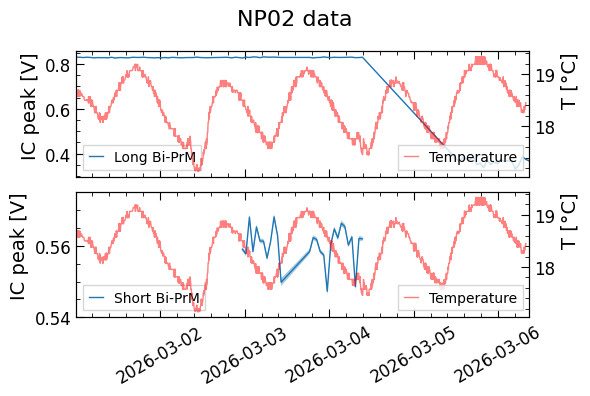

In [12]:
fig, ax = plt.subplots(figsize=(6, 2.*2), nrows=2, layout='tight')

ax[0].plot(Output.Date, Output.LongIC_Peak, lw=1, label='Long Bi-PrM')
ax[0].fill_between(Output.Date, Output.LongIC_Peak-Output.LongIC_PeakErr, Output.LongIC_Peak+Output.LongIC_PeakErr, alpha=0.4)
pmana.utils.plotting.UpdateMatplotlibStyle(ax[0], None, 'IC peak [V]')
ax[0].set_xticklabels([])
# ax[0].set_ylim(0.82, 0.835)

ax[1].plot(Output_v2.Date, Output_v2.ShortIC_Peak, lw=1, label='Short Bi-PrM')
ax[1].fill_between(Output_v2.Date, Output_v2.ShortIC_Peak-Output_v2.ShortIC_PeakErr, Output_v2.ShortIC_Peak+Output_v2.ShortIC_PeakErr, alpha=0.4)
pmana.utils.plotting.UpdateMatplotlibStyle(ax[1], None, 'IC peak [V]')
ax[1].set_ylim(0.54, 0.575)

for a in ax:
  # gfx
  a.legend(frameon=True, fancybox=False, handlelength=1, fontsize=10, loc='lower left')
  a.tick_params(axis='x', labelrotation=30)
  a.set_xlim(Output['Date'].iloc[0], Output['Date'].iloc[-1])

  # plot temperatures
  a2 = a.twinx()
  a2.plot(Temperatures['Date'], Temperatures['T'], c='red', label='Temperature', lw=1, alpha=0.5, zorder=-3)
  pmana.utils.plotting.UpdateMatplotlibStyle(a2, None, 'T [°C]')
  a2.legend(frameon=True, fancybox=False, handlelength=1, fontsize=10, loc='lower right')

# ax.set_ylim(0.822, 0.835)
# a2.set_ylim(16, 20)

fig.suptitle(f'NP02 data', fontsize=16)

plt.show()
fig.savefig(f"../../plots/cern/IC_Peaks_{TIME_DIR}.png", dpi=300, bbox_inches='tight')

In [13]:
# get UV-PrM data
UV_PURITY_DATA = "/Users/triozzi/Analysis/pmana/data/cern_csv/prm_Top_lifetime_data_Gain_InducedCurrent_TPC - prm_Top_lifetime_data_Gain_InducedCurrent_TPC.csv"

UVData = pandas.read_csv(
  UV_PURITY_DATA,
  delimiter = '\t',
  names = ['Date', 'PM', 'Center', 'High', 'Low'],
  skiprows=1 
)

# some more formatting...
UVData['Date'] = pandas.to_datetime(
    UVData['Date']
)

[0.83142003 0.83342003 0.83542003 0.83742003 0.83942003 0.84142003
 0.84342003 0.84542003 0.84742003 0.84942003 0.85142003 0.85342003
 0.85542003 0.85742003 0.85942003 0.86142003 0.86342003 0.86542003
 0.86742003 0.86942003 0.87142003 0.87342003 0.87542003 0.87742003
 0.87942003 0.88142003]


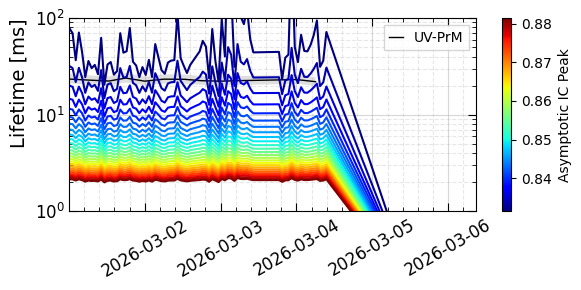

In [14]:
# check electron lifetime with respect to IC peak
fig, ax = plt.subplots(figsize=(6, 3), nrows=1, layout='tight')

# plot UV-PrM data
ax.plot(UVData.Date, UVData.Center, lw=1, c='black', label='UV-PrM')
ymin = numpy.minimum.reduce([UVData.Low, UVData.Center, UVData.High])
ymax = numpy.maximum.reduce([UVData.Low, UVData.Center, UVData.High])
ax.fill_between(UVData.Date, ymin, ymax, fc='gray', alpha=0.25)

# some example fo asymptotic IC peaks
ASYMPTOTIC_IC_PEAKS = numpy.arange(Output['LongIC_Peak'].max(), Output['LongIC_Peak'].max() + 0.05, 0.002)
print(ASYMPTOTIC_IC_PEAKS)
cmap = matplotlib.colormaps.get_cmap('jet')
norm = matplotlib.colors.Normalize(vmin=ASYMPTOTIC_IC_PEAKS.min(), vmax=ASYMPTOTIC_IC_PEAKS.max())

for ICPeak_asymptotic in ASYMPTOTIC_IC_PEAKS:

  # get lifetime for an asymptotic hypothesis
  Output['Lifetime'] = pmana.purity.ana.GetLifetime_SinglePrM(
    Output['LongIC_Peak'],
    ICPeak_asymptotic
  )

  # plot the lifetime extracted in this way
  ax.plot(Output['Date'], Output['Lifetime']/1.e3, color=cmap(norm(ICPeak_asymptotic)))

# add colorbar
sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for matplotlib < 3.7
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Asymptotic IC Peak')

# gfx
pmana.utils.plotting.UpdateMatplotlibStyle(ax, None, 'Lifetime [ms]')
ax.tick_params(axis='x', labelrotation=30)
ax.grid(which='major', alpha=0.5)
ax.grid(which='minor', ls='--', alpha=0.3)
ax.set_yscale('log')
ax.set_xlim(Output['Date'].min(), Output['Date'].max())
ax.set_ylim(1, 100)

plt.show()
fig.savefig(f"../../plots/cern/IC_Peaks_Asymptotic_{TIME_DIR}.png", dpi=300, bbox_inches='tight')

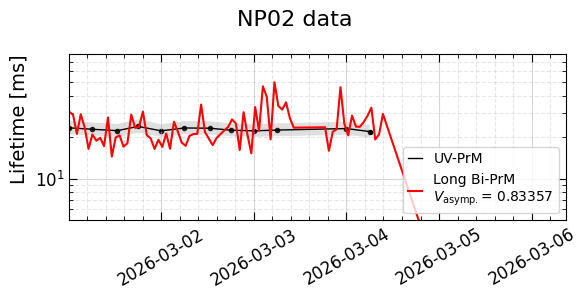

In [15]:
# check electron lifetime with respect to IC peak
fig, ax = plt.subplots(figsize=(6, 3), nrows=1, layout='tight')

# plot UV-PrM data
ax.scatter(UVData.Date, UVData.Center, marker='.', c='black')
ax.plot(UVData.Date, UVData.Center, lw=1, c='black', label='UV-PrM')
ymin = numpy.minimum.reduce([UVData.Low, UVData.Center, UVData.High])
ymax = numpy.maximum.reduce([UVData.Low, UVData.Center, UVData.High])
ax.fill_between(UVData.Date, ymin, ymax, fc='gray', alpha=0.25)

# plot lifetime from Bi-PrM data
IC_PEAK_ASYMPTOTIC = 0.83357082
Output['Lifetime'] = pmana.purity.ana.GetLifetime_SinglePrM(
  Output['LongIC_Peak'],
  IC_PEAK_ASYMPTOTIC
)
ax.plot(Output['Date'], Output['Lifetime']/1.e3, c='red', label='Long Bi-PrM\n$V_\\mathrm{asymp.}$' + f'= {IC_PEAK_ASYMPTOTIC:.5f}')

# gfx
pmana.utils.plotting.UpdateMatplotlibStyle(ax, None, 'Lifetime [ms]')
ax.legend(handlelength=1, loc='lower right')
ax.tick_params(axis='x', labelrotation=30)
ax.grid(which='major', alpha=0.5)
ax.grid(which='minor', ls='--', alpha=0.3)
ax.set_yscale('log')
ax.set_xlim(Output['Date'].min(), Output['Date'].max())
ax.set_ylim(5, 80)

fig.suptitle(f'NP02 data', fontsize=16)

plt.show()
fig.savefig(f"../../plots/cern/IC_Peaks_Asymptotic_Comparison_{TIME_DIR}.png", dpi=300, bbox_inches='tight')

#### Purity analysis, but save spectra 

This is not good practice. But can be super useful to check if the analysis did good.

In [26]:
# analyze campaign
TIME_DIR = f"2026_Mar"
PATH_CAMPAIGN = f"../../data/cern_csv/{TIME_DIR}"

CalibrationFactors = {
  0: 1,
  1: 0.9,
  2: 1,
  3: 1
}

ANALYSIS_CONFIGURATION = {
    'InnerLongChannel'          : 0,
    'OuterLongChannel'          : 1,
    'InnerShortChannel'         : 3,
    'OuterShortChannel'         : 2,  
    'ShortGausFitLimits'        : (0.15, 0.15),
    'LongGausFitLimits'         : (0.1, 0.15),
    'ComptonSearchLimits'       : (0.5, 1),
    'MinComptonSearchLowLimit'  : 0.25,
    'ComptonMode'               : 'rising',
    'LongICPeakSearchLimits'    : (0.4, 1),
    'ShortICPeakSearchLimits'   : (0.4, 1),
}

Output = pmana.utils.iterators.IterateCERN_CSV(
    PATH_CAMPAIGN,  ###< path to data
    # pmana.utils.anatestdata.AnalyzeMeasurement, 
    functools.partial(
        pmana.purity.ana.ExtractICPeak, 
        CALIBRATION_FACTORS = CalibrationFactors,
        PM_TAG = 'Long',
        SAVE_SPECTRA = True, ###< save the spectra on the dataframe
        ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
    )  ###< analyzing module, changing some options 
)

# convert top DataFrame
Output = pandas.DataFrame(Output)

# re-format the dataframe
Output.columns = [
  "LongIC_Peak", "LongIC_PeakErr", "LongIC_Scale",
  "xIC", "IC",
  "Date"
]

# sort by date
Output.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_00_10.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_01_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_02_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_03_11.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_04_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_05_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_06_12.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_07_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_08_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_09_13.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_10_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_11_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_12_14.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_01_13_15.csv...
Analyz

There were 4 used channels in this measurement.
Results for this measurement:
    LongIC_Peak  LongIC_PeakErr  LongIC_Scale  \
5      0.80869        0.000661      1.136548   

                                                 xIC  \
5  [0.203, 0.205, 0.207, 0.209, 0.211, 0.213, 0.2...   

                                                  IC                Date  
5  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ... 2026-03-01 05:12:00  


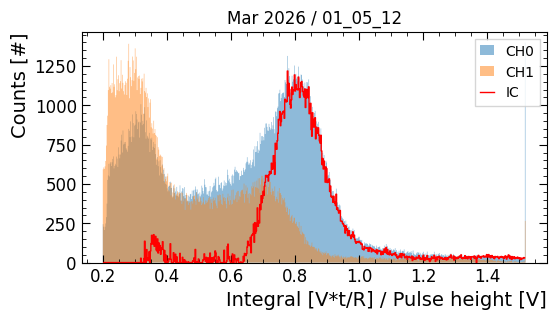

In [27]:
fig, ax = plt.subplots(figsize=(6,3))

YEAR = '2026'
MONTH = 'Mar'
MEASUREMENT = f'01_05_12'
FILE_PATH = f"../../data/cern_csv/{YEAR}_{MONTH}/Record_{YEAR}_{MONTH}_{MEASUREMENT}.csv"

# extract a measurement 
Data = pmana.utils.io.ExtractSingleMeasurement(
    FILE_PATH,
    IS_CSV = True,
    COL_NAMES = ['binCenter', 'F1', 'F2', 'F3', 'F4'],
    DELIMITER = ","
)
print(f"There were {len(Data)} used channels in this measurement.")

CHs = [1, 2]
for ch in CHs:
    # plot channel data
    pmana.utils.plotting.PlotSingleChannel(
        Data[ch-1],
        ax,
        channel = ch-1,
        rebin = False,
        debug = False,
        DISPLAY_FIT = False
    )

ax = pmana.utils.plotting.UpdateMatplotlibStyle(
    ax,
    "Integral [V*t/R] / Pulse height [V]",
    "Counts [#]"
)

# plot the corresponding IC peak
MONTH_ABBR = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
DAY, HOUR, MINUTE = MEASUREMENT.split('_')
EXACT_DATE = datetime.datetime(
    int(YEAR), 
    int(MONTH_ABBR[MONTH]),
    int(DAY),
    int(HOUR),
    int(MINUTE)
)
Mask = Output['Date'] == EXACT_DATE
print("Results for this measurement:\n", Output[Mask])
xIC = Output[Mask].iloc[0]['xIC']
IC = Output[Mask].iloc[0]['IC']
ax.step(
    xIC, 
    IC,
    where = 'mid',
    c = 'red',
    lw = 1,
    label = 'IC'
)

ax.legend(handlelength=1, loc='upper right', frameon=True, fancybox=False)
ax.set_title(f"{MONTH} {YEAR} / {MEASUREMENT}")
plt.show()
fig.savefig(f"../../plots/cern/RawData_IC_{YEAR}_{MONTH}.png", dpi=300, bbox_inches='tight')

In [15]:
1 - 0.694946 / 0.827262

0.15994449158791302

In [19]:
0.02 * 1.495 + 1.495

1.5249000000000001

In [20]:
# analyze campaign
TIME_DIR = f"2026_Mar"
PATH_CAMPAIGN = f"../../data/cern_csv/{TIME_DIR}"

CalibrationFactors = {
  0: 1,
  1: 1,
  2: 1.495,
  3: 1.525
}

ANALYSIS_CONFIGURATION = {
    'InnerLongChannel'          : 0,
    'OuterLongChannel'          : 1,
    'InnerShortChannel'         : 3,
    'OuterShortChannel'         : 2,  
    'ShortGausFitLimits'        : (0.15, 0.15),
    'LongGausFitLimits'         : (0.1, 0.15),
    'ComptonSearchLimits'       : (0.5, 1),
    'MinComptonSearchLowLimit'  : 0.25,
    'ComptonMode'               : 'rising',
    'LongICPeakSearchLimits'    : (0.4, 1),
    'ShortICPeakSearchLimits'   : (0.4, 1),
}

Output = pmana.utils.iterators.IterateCERN_CSV(
  PATH_CAMPAIGN,  ###< path to data
  # pmana.utils.anatestdata.AnalyzeMeasurement, 
  functools.partial(
      pmana.purity.ana.ExtractICPeak, 
      CALIBRATION_FACTORS = CalibrationFactors,
      PM_TAG = 'Short',
      SAVE_SPECTRA = True, ###< save the spectra on the dataframe
      ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
  ),  ###< analyzing module, changing some options 
  START_FROM = datetime.datetime(2026, 3, 3, 0, 22),
)

# convert top DataFrame
Output = pandas.DataFrame(Output)

# re-format the dataframe
Output.columns = [
  "ShortIC_Peak", "ShortIC_PeakErr", "ShortIC_Scale",
  "xIC", "IC",
  "Date"
]

# sort by date
Output.sort_values(
    by = 'Date', 
    inplace = True,
    ignore_index = True
)

Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_00_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_01_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_02_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_03_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_04_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_05_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_06_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_07_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_08_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_09_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_10_22.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_18_28.csv...
Analyzing ../../data/cern_csv/2026_Mar/Record_2026_Mar_03_19_28.csv...


There were 4 used channels in this measurement.
Results for this measurement:
     ShortIC_Peak  ShortIC_PeakErr  ShortIC_Scale  \
10      0.819435         0.001111       1.165621   

                                                  xIC  \
10  [0.2024, 0.204, 0.2056, 0.2072, 0.2088, 0.2104...   

                                                   IC                Date  
10  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ... 2026-03-03 10:22:00  


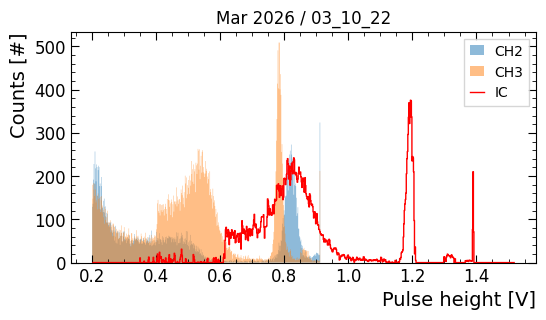

In [21]:
fig, ax = plt.subplots(figsize=(6,3))

YEAR = '2026'
MONTH = 'Mar'
MEASUREMENT = f'03_10_22'
FILE_PATH = f"../../data/cern_csv/{YEAR}_{MONTH}/Record_{YEAR}_{MONTH}_{MEASUREMENT}.csv"

# extract a measurement 
Data = pmana.utils.io.ExtractSingleMeasurement(
    FILE_PATH,
    IS_CSV = True,
    COL_NAMES = ['binCenter', 'F1', 'F2', 'F3', 'F4'],
    DELIMITER = ","
)
print(f"There were {len(Data)} used channels in this measurement.")

CHs = [3, 4]
for ch in CHs:
    # plot channel data
    pmana.utils.plotting.PlotSingleChannel(
        Data[ch-1],
        ax,
        channel = ch-1,
        rebin = False,
        debug = False,
        DISPLAY_FIT = False
    )

ax = pmana.utils.plotting.UpdateMatplotlibStyle(
    ax,
    "Pulse height [V]",
    "Counts [#]"
)

# plot the corresponding IC peak
MONTH_ABBR = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
DAY, HOUR, MINUTE = MEASUREMENT.split('_')
EXACT_DATE = datetime.datetime(
    int(YEAR), 
    int(MONTH_ABBR[MONTH]),
    int(DAY),
    int(HOUR),
    int(MINUTE)
)
Mask = Output['Date'] == EXACT_DATE
print("Results for this measurement:\n", Output[Mask])
xIC = Output[Mask].iloc[0]['xIC']
IC = Output[Mask].iloc[0]['IC']
ax.step(
    xIC, 
    IC,
    where = 'mid',
    c = 'red',
    lw = 1,
    label = 'IC'
)

ax.legend(handlelength=1, loc='upper right', frameon=True, fancybox=False)
ax.set_title(f"{MONTH} {YEAR} / {MEASUREMENT}")
plt.show()
fig.savefig(f"../../plots/cern/RawData_IC_Short_{YEAR}_{MONTH}.png", dpi=300, bbox_inches='tight')